<a href="https://colab.research.google.com/github/emilly-kelda/kitesurf-school-analytics/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kitesurf School Analytics: Data, Operations & Performance Insights

### Project Overview

This project explores how data systems and analytics can enhance operations in the watersports industry. By simulating a kitesurf school environment, it integrates database design, data analysis, and visualization to uncover patterns in bookings, pricing, and equipment usage.

This project is part of a broader goal to apply technology and AI to optimize real-world sports and hospitality operations.

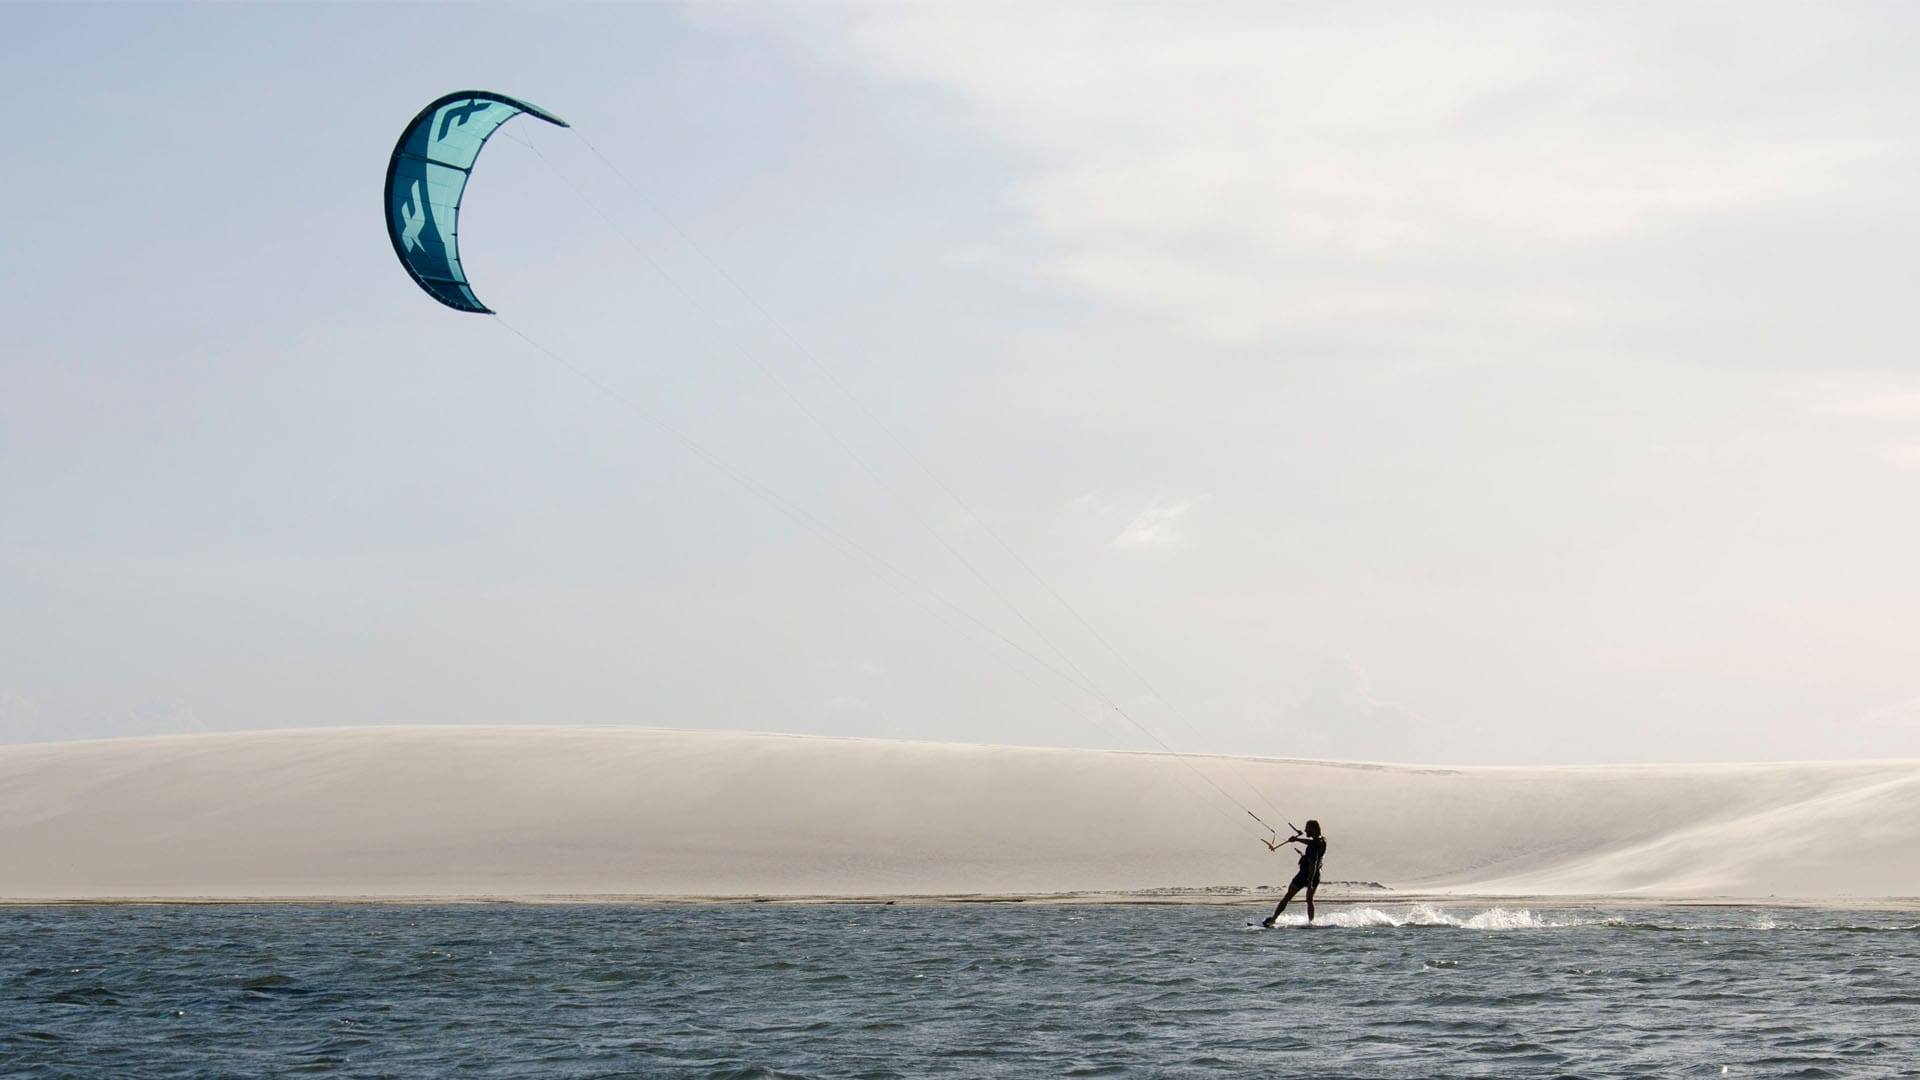

## Create SQLite Database from DataFrame

In [88]:
import sqlite3

# Create a new SQLite database and connect to it
conn = sqlite3.connect('watersports.db')

# Write the DataFrame to a SQL table named 'bookings'
df.to_sql('bookings', conn, if_exists='replace', index=False)

print("DataFrame successfully written to SQLite database 'watersports.db' as table 'bookings'.")

# Close the connection for now, it will be reopened for queries later
conn.close()

DataFrame successfully written to SQLite database 'watersports.db' as table 'bookings'.


## Import Libraries

In [89]:
import pandas as pd
import random
from datetime import datetime, timedelta

## Create realistic data pools

In [90]:
students = ["Lucas Silva", "Ana Costa", "Pedro Santos", "Maria Oliveira", "João Souza", "Carla Mendes"]

instructors = ["Pedro", "Marcos", "Julia", "Fernanda"]

sports = ["kitesurf", "windsurf", "wingfoil"]

equipment_map = {
    "kitesurf": ["9m kite", "12m kite", "7m kite"],
    "windsurf": ["windsurf board"],
    "wingfoil": ["foil board"]
}

prices = {
    "kitesurf": (300, 500),
    "windsurf": (200, 400),
    "wingfoil": (250, 450)
}

## Random date function

In [7]:
def random_date():
    start_date = datetime(2025, 1, 1)
    end_date = datetime(2026, 3, 1)
    delta = end_date - start_date
    random_days = random.randint(0, delta.days)
    return (start_date + timedelta(days=random_days)).strftime("%Y-%m-%d")

## Seasonal Pricing Logic

In [8]:
def seasonal_price(sport, date):
    month = int(date.split("-")[1])

    base_min, base_max = prices[sport]

    # Peak wind season (higher demand)
    if month in [6, 7, 8]:
        return random.randint(base_min + 50, base_max + 100)

    return random.randint(base_min, base_max)

## Generate Dataset

In [91]:
data = []

for _ in range(200):
    sport = random.choice(sports)
    date = random_date()

    row = {
        "date": date,
        "student_name": random.choice(students),
        "instructor": random.choice(instructors),
        "sport": sport,
        "equipment": random.choice(equipment_map[sport]),
        "price": seasonal_price(sport, date),
        "duration_hours": random.choice([1, 1.5, 2, 2.5, 3])
    }

    data.append(row)

## Create DataFrame

In [10]:
df = pd.DataFrame(data)

## Preview Data

In [92]:
df.head()

,date,student_name,instructor,sport,equipment,price,duration_hours,month,month_name,cost,profit,profit_per_hour
0,2025-01-08,Pedro Santos,Julia,wingfoil,foil board,360,3.00,1,January,150.00,210.00,70.00
1,2025-04-08,Ana Costa,Marcos,wingfoil,foil board,363,1.00,4,April,50.00,313.00,313.00
2,2025-07-17,Ana Costa,Julia,kitesurf,7m kite,497,1.00,7,July,50.00,447.00,447.00
3,2025-09-19,Pedro Santos,Pedro,kitesurf,7m kite,464,1.50,9,September,75.00,389.00,259.33
4,2025-08-07,Carla Mendes,Pedro,wingfoil,foil board,381,1.00,8,August,50.00,331.00,331.00


## Data Validation

In [18]:
# Set display format for cleaner tables
pd.options.display.float_format = '{:.2f}'.format

In [19]:
df.describe()

,price,duration_hours
count,200.00,200.00
mean,369.68,1.94
std,82.98,0.73
min,209.00,1.00
25%,304.75,1.00
50%,363.50,2.00
75%,433.00,2.50
max,593.00,3.00


In [20]:
df['sport'].value_counts()

,count
sport,
wingfoil,71
windsurf,68
kitesurf,61


In [21]:
df['instructor'].value_counts()

,count
instructor,
Pedro,60
Julia,53
Fernanda,48
Marcos,39


## Save & Export

In [22]:
df.to_csv("bookings.csv", index=False)

In [23]:
from google.colab import files
files.download("bookings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Feature Engineering

In [24]:
# Revenue per hour
df['revenue_per_hour'] = df['price'] / df['duration_hours']

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Extract month
df['month'] = df['date'].dt.month

## Revenue Analysis

In [30]:
# Total revenue
df['price'].sum()

np.int64(73935)

In [29]:
# Revenue by instructor
df.groupby('instructor')['price'].sum().sort_values(ascending=False)

,price
instructor,
Pedro,22647
Julia,19691
Fernanda,17899
Marcos,13698


## Monthly Revenue by Sport

In [71]:
# Ensure 'date' is datetime and 'month' is extracted
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Create month_name and order months correctly
df['month_name'] = df['date'].dt.month_name()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

monthly_revenue_by_sport = df.groupby(['month_name', 'sport'], observed=False)['price'].sum().unstack(fill_value=0)

# Display the result
display(monthly_revenue_by_sport)

sport,kitesurf,windsurf,wingfoil
month_name,,,
January,2338,3043,4812
February,2779,3235,2678
March,1743,1255,2387
April,2090,1159,891
May,466,1078,1961
June,3038,1591,1810
July,4020,2903,347
August,906,2713,3254
September,1333,978,2753


From this table, we can observe:

*   **Kitesurf**: Shows higher revenue in July (4020) and November (2307), indicating potential peak seasons or higher demand for kitesurfing during these months.
*   **Windsurf**: Peaks in January (3043) and August (2713), suggesting these are strong months for windsurfing activities.
*   **Wingfoil**: Appears to have strong revenue in January (4812) and August (3254), similar to windsurf, indicating its popularity during these periods.

Months with `0` revenue indicate no bookings were recorded for that sport during that specific month in the simulated data. This breakdown is crucial for understanding seasonal trends and optimizing resource allocation or marketing efforts for each sport.

## Efficiency Analysis

In [36]:
df['revenue_per_hour'].describe()

,revenue_per_hour
count,200.00
mean,225.17
std,109.15
min,72.33
25%,140.95
50%,193.67
75%,289.92
max,593.00


## Seasonality Analysis

In [42]:
# Create month and month name
df['date'] = pd.to_datetime(df['date'])
df['month_name'] = df['date'].dt.month_name()

# Order months correctly
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

# Revenue by month
df.groupby('month_name', observed=False)['price'].sum().rename("total_revenue")

,total_revenue
month_name,
January,10193
February,8692
March,5385
April,4140
May,3505
June,6439
July,7270
August,6873
September,5064


## Profit Simulation

In [43]:
# Assume instructor cost per hour = 50
df['cost'] = df['duration_hours'] * 50

df['profit'] = df['price'] - df['cost']

df['profit'].describe()

,profit
count,200.00
mean,272.93
std,91.45
min,67.00
25%,209.50
50%,269.00
75%,333.25
max,543.00


## Monthly Profit by Instructor

In [80]:
monthly_profit_by_instructor = df.groupby(['month_name', 'instructor'], observed=False)['profit'].sum().unstack(fill_value=0)

# Display the result
display(monthly_profit_by_instructor)

instructor,Fernanda,Julia,Marcos,Pedro
month_name,,,,
January,1950.00,1968.00,1273.00,1977.00
February,998.00,2034.00,1295.00,2140.00
March,645.00,1194.00,1046.00,1125.00
April,624.00,584.00,795.00,962.00
May,980.00,660.00,417.00,223.00
June,2342.00,1683.00,765.00,274.00
July,1093.00,1495.00,1370.00,1862.00
August,2305.00,685.00,917.00,1441.00
September,0.00,1892.00,0.00,1922.00


## Visualization

<Figure size 1200x700 with 0 Axes>

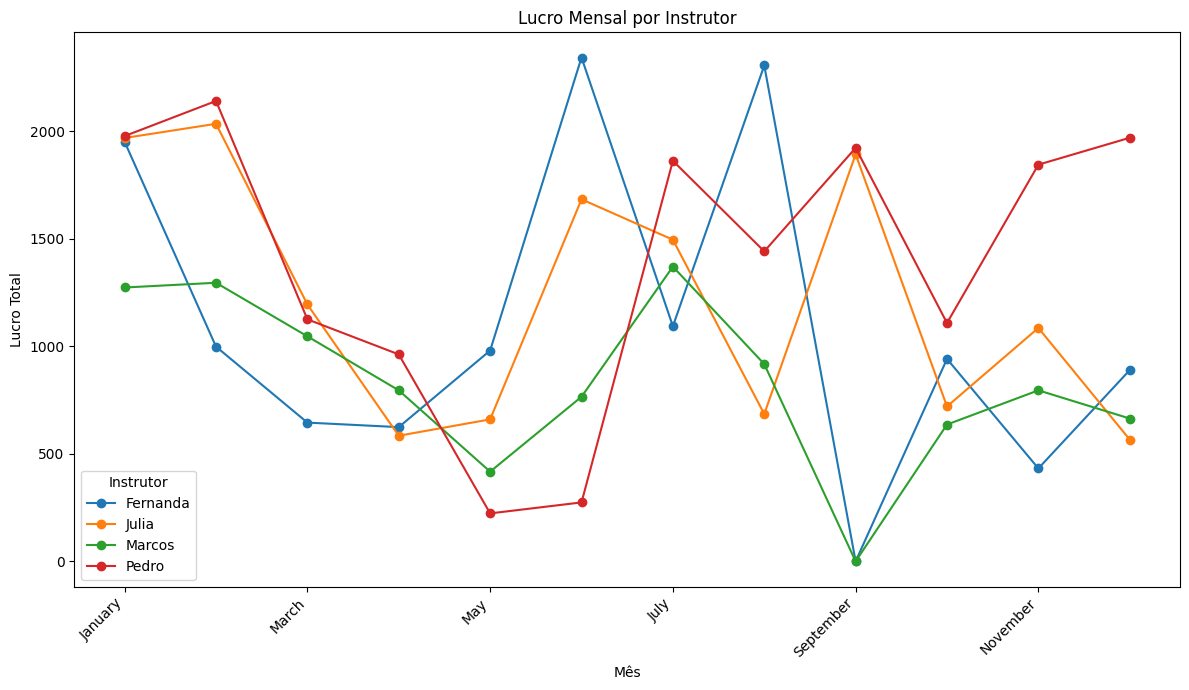

In [93]:
import matplotlib.pyplot as plt

# Create the line plot
plt.figure(figsize=(12, 7))
monthly_profit_by_instructor.plot(kind='line', marker='o', figsize=(12, 7))

# Set the title and labels
plt.title('Lucro Mensal por Instrutor')
plt.xlabel('Mês')
plt.ylabel('Lucro Total')

# Add a legend to differentiate instructors
plt.legend(title='Instrutor')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()


The analysis revealed distinct profitability trends for each instructor throughout the year, highlighting individual performance variations and seasonal patterns.

Pedro and Julia generally exhibited higher and more consistent monthly profits, while Fernanda showed strong performance in specific summer months (June and August) but also a notable month with no profit.

Marcos consistently had the lowest monthly profits among the instructors. Seasonal trends indicated peaks for most instructors early in the year (January/February) and during summer (July), with a general low season observed for all instructors in April and May.

### Data Analysis Key Findings
*   **Pedro** consistently maintained high profits, with peaks in February (\$2140), January (\$1977), and July (\$1862). His lowest profits were in May (\$223) and June (\$274).
*   **Julia** showed strong performance early in the year, peaking in February (\$2034) and January (\$1968), and also had a good June (\$1683). Her lowest months were May (\$660) and August (\$685).
*   **Fernanda** demonstrated exceptional performance in June (\$2342) and August (\$2305) and a strong January (\$1950). However, she had no recorded profit in September (\$0), and her lowest months were March (\$645) and April (\$624).
*   **Marcos** generally had the lowest monthly profits, with peaks in July (\$1370), February (\$1295), and January (\$1273). His lowest profits were in May (\$417) and June (\$765).
*   **Seasonal Trends**: January, February, and July were common peak months for most instructors, while April and May were generally periods of lower profit across all instructors.
*   **Individual Consistency**: Pedro and Julia showed more stable and higher profit generation overall, whereas Fernanda displayed significant fluctuations, including a zero-profit month.

### Insights or Next Steps
*   Investigate the reason behind Fernanda's zero profit in September and Marcos's consistently lower profit figures to understand potential underlying issues such as workload allocation, vacation periods, or specific market demand for their services.
*   Develop targeted strategies for low-profit months (April and May) for all instructors, and explore ways to leverage the strong performance of Pedro and Julia, perhaps by assigning them to high-value projects or training new instructors.


## Total Profit per Instructor

The data indicates that Pedro generates the highest total profit for the school, followed by Julia, Fernanda, and Marcos. This could be due to a variety of factors, such as the number of sessions taught, the type of sessions, or the duration of sessions.

In [76]:
df.groupby('instructor')['profit'].sum().sort_values(ascending=False)

,profit
instructor,
Pedro,16847.00
Julia,14566.00
Fernanda,13199.00
Marcos,9973.00


## Instructor Profitability Visualization

This code block will perform these operations using pandas for aggregation and matplotlib for plotting, following the instructions provided.



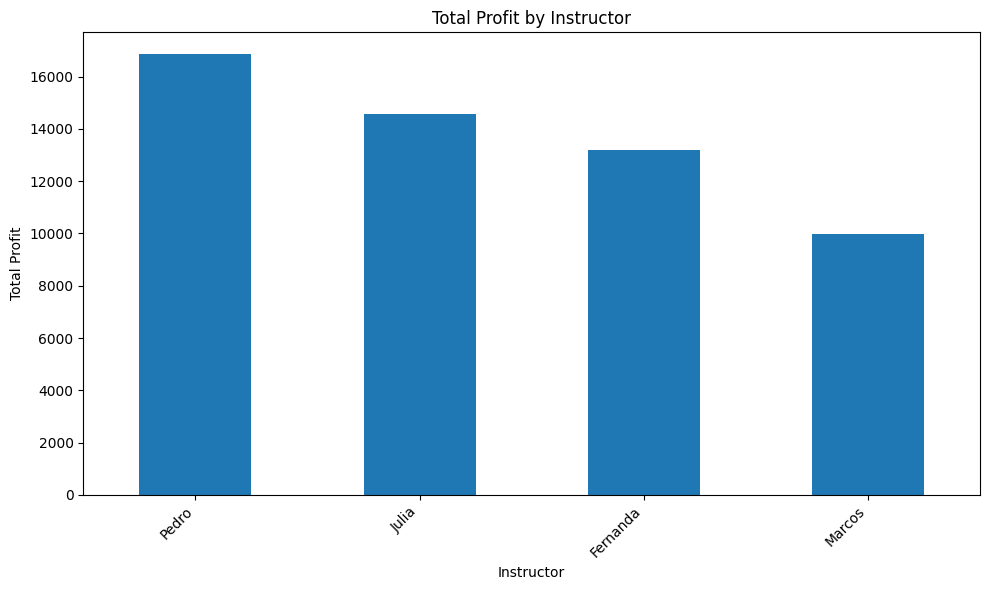

In [78]:
import matplotlib.pyplot as plt

# Calculate the total profit for each instructor
instructor_profit = df.groupby('instructor')['profit'].sum().sort_values(ascending=False)

# Set a larger figure size for better readability
plt.figure(figsize=(10, 6))

# Create a bar chart
instructor_profit.plot(kind='bar')

# Set the title of the plot
plt.title('Total Profit by Instructor')

# Label the x-axis
plt.xlabel('Instructor')

# Label the y-axis
plt.ylabel('Total Profit')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right') # ha='right' aligns the rotated labels properly

# Adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

## Hourly Revenue per Sport

In [34]:
df.groupby('sport')['revenue_per_hour'].mean().sort_values(ascending=False)

,revenue_per_hour
sport,
kitesurf,269.76
wingfoil,225.15
windsurf,185.18


## Monthly Revenue by Sport Visualization

A stacked bar chart is generated to visualize monthly revenue by sport using the `monthly_revenue_by_sport` DataFrame. This involves importing `matplotlib.pyplot`, creating the plot with specific parameters, setting labels and titles, and displaying it.



<Figure size 1200x700 with 0 Axes>

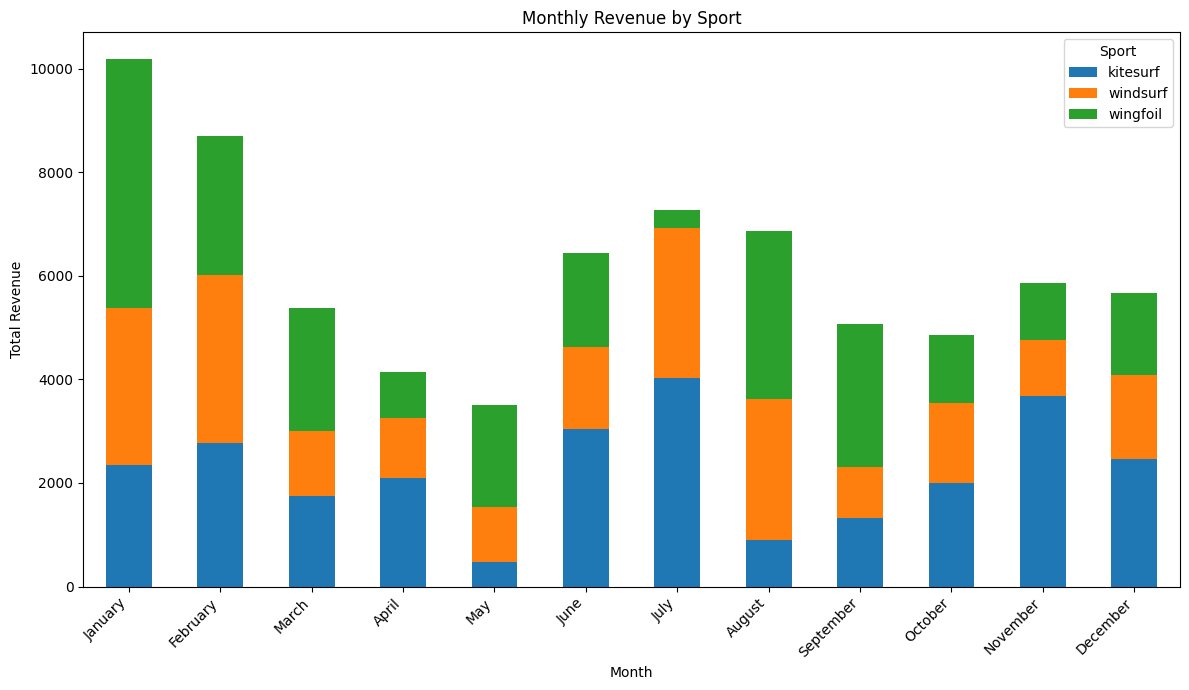

In [77]:
import matplotlib.pyplot as plt

# Set a larger figure size for better readability
plt.figure(figsize=(12, 7))

# Create a stacked bar chart
monthly_revenue_by_sport.plot(kind='bar', stacked=True, figsize=(12, 7))

# Set the title of the plot
plt.title('Monthly Revenue by Sport')

# Label the x-axis
plt.xlabel('Month')

# Label the y-axis
plt.ylabel('Total Revenue')

# Add a legend to distinguish between sports
plt.legend(title='Sport')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right') # ha='right' aligns the rotated labels properly

# Adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

### Summary of Monthly Revenue by Sport Visualization

The stacked bar chart reveals several key insights regarding the kitesurf school's monthly revenue across different sports:

*   **Overall Revenue Peaks**: The highest total revenue months appear to be January, July, and August. January stands out with significant contributions from Wingfoil and Windsurf.
*   **Sport-Specific Peaks**:
    *   **Wingfoil**: Consistently contributes significantly, with strong performance in January and August. It appears to be a major revenue driver, especially in the early and mid-year.
    *   **Windsurf**: Shows peaks in January, February, and August. Its contribution is notable, often complementing other sports.
    *   **Kitesurf**: While having some high months like July and November, its overall contribution is more spread out compared to Wingfoil's dominant peaks. July is a particularly strong month for Kitesurf.
*   **Seasonal Trends**:
    *   **Winter/Spring (January - March)**: Strong start to the year, particularly driven by Wingfoil and Windsurf. There's a noticeable dip in total revenue from April to May.
    *   **Summer (June - August)**: A resurgence in revenue, with July and August being strong months. Kitesurf sees a boost in July, while Wingfoil and Windsurf also perform well in August.
    *   **Autumn/Winter (September - December)**: Revenue generally stabilizes, with Kitesurf showing a good performance in November.
*   **Low Revenue Periods**: April and May show the lowest total revenue, suggesting a potential off-peak season where demand for all sports is lower.

These insights can help the school in resource allocation, marketing strategies, and pricing adjustments throughout the year to maximize profitability.

### Data Analysis Key Findings
*   The highest total revenue months are January, July, and August.
*   Wingfoil is a consistent major revenue driver, particularly strong in January and August.
*   Windsurf shows revenue peaks in January, February, and August.
*   Kitesurf's strongest months are July and November.
*   April and May are the months with the lowest overall revenue.
*   Revenue shows a strong start in Winter/Spring (January-March), dips in Spring (April-May), resurges in Summer (June-August), and stabilizes in Autumn/Winter (September-December).

### Insights or Next Steps
*   The school can leverage these insights to optimize resource allocation, tailor marketing strategies, and adjust pricing throughout the year to maximize profitability, especially by targeting marketing efforts for specific sports during their peak seasons.
*   Further investigation into the reasons for the low revenue in April and May could help in developing strategies (e.g., promotions, new offerings) to mitigate this off-peak dip.


## Profit per session

Pedro generates the highest total profit, largely due to handling more sessions. However, he also maintains the highest profit per session, indicating both high productivity and strong efficiency.

Marcos, on the other hand, has lower total profit and slightly lower efficiency, suggesting both lower workload and potential performance differences.

In [46]:
df.groupby('instructor')['profit'].mean()

,profit
instructor,
Fernanda,274.98
Julia,274.83
Marcos,255.72
Pedro,280.78


## Profit vs Session Duration

In [44]:
df.groupby('duration_hours')['profit'].mean()

,profit
duration_hours,
1.00,316.94
1.50,302.21
2.00,281.69
2.50,230.88
3.00,220.41


## Profit vs. Session Duration Visualization

This visualization show the trend of decreasing profitability with longer sessions, which was identified as a key insight.

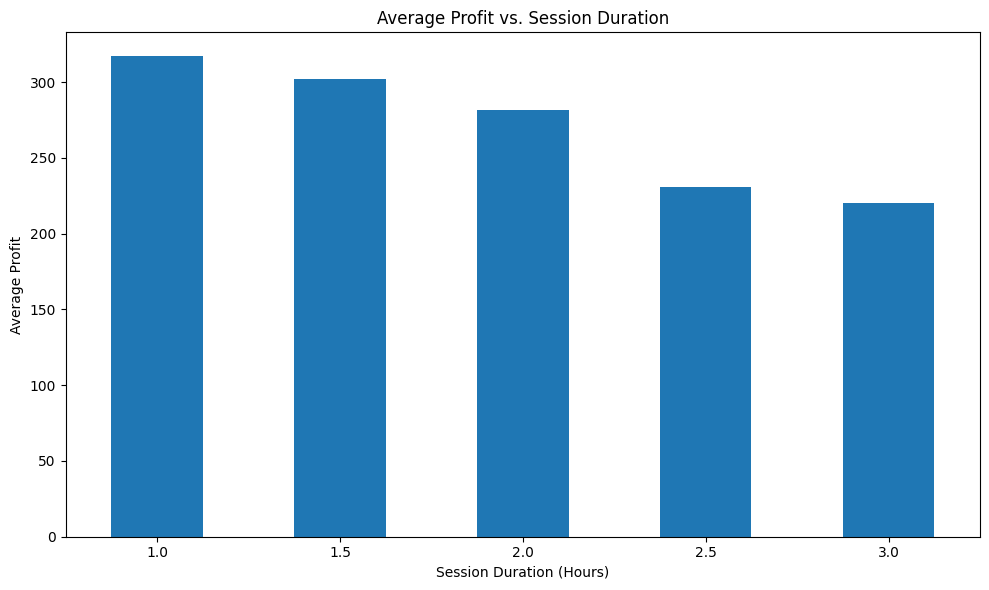

In [79]:
import matplotlib.pyplot as plt

# Calculate the average profit for each session duration
profit_per_duration = df.groupby('duration_hours')['profit'].mean()

# Set a larger figure size for better readability
plt.figure(figsize=(10, 6))

# Create a bar chart for average profit by duration
profit_per_duration.plot(kind='bar')

# Set the title of the plot
plt.title('Average Profit vs. Session Duration')

# Label the x-axis
plt.xlabel('Session Duration (Hours)')

# Label the y-axis
plt.ylabel('Average Profit')

# Rotate the x-axis labels if necessary for better readability
plt.xticks(rotation=0)

# Adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

### Data Analysis Key Findings
*   The average profit per session **decreases progressively** as the session duration increases.
*   **1-hour sessions** are the most profitable, with an average profit of \$316.94.
*   **3-hour sessions** are the least profitable, generating an average profit of \$220.41.
*   Intermediate session durations show a consistent decline in average profit:
    *   1.5-hour sessions: \$302.21
    *   2.0-hour sessions: \$281.69
    *   2.5-hour sessions: \$230.88

### Insights or Next Steps
*   The kitesurf school should **re-evaluate and adjust its pricing structure** for longer sessions to ensure they are profitable, potentially by increasing the hourly rate for extended durations or offering packages that incentivize more profitable session lengths.
*   Conduct a **detailed cost analysis** for each session duration to identify all direct and indirect expenses, ensuring that pricing adequately covers costs and generates a healthy profit margin across all offerings.


## Equipment Usage Count Analysis

Calculate the total number of times each unique piece of equipment has been used across all bookings.


In [83]:
equipment_usage_count = df['equipment'].value_counts()
print(equipment_usage_count)

equipment
foil board        71
windsurf board    68
7m kite           22
12m kite          20
9m kite           19
Name: count, dtype: int64


## Analyze Revenue by Equipment

Calculate the total revenue generated by each unique piece of equipment.


In [85]:
equipment_revenue = df.groupby('equipment')['price'].sum().sort_values(ascending=False)
print(equipment_revenue)

equipment
foil board        24882
windsurf board    22197
7m kite            9984
12m kite           8632
9m kite            8240
Name: price, dtype: int64


## Visualize Equipment Usage and Revenue

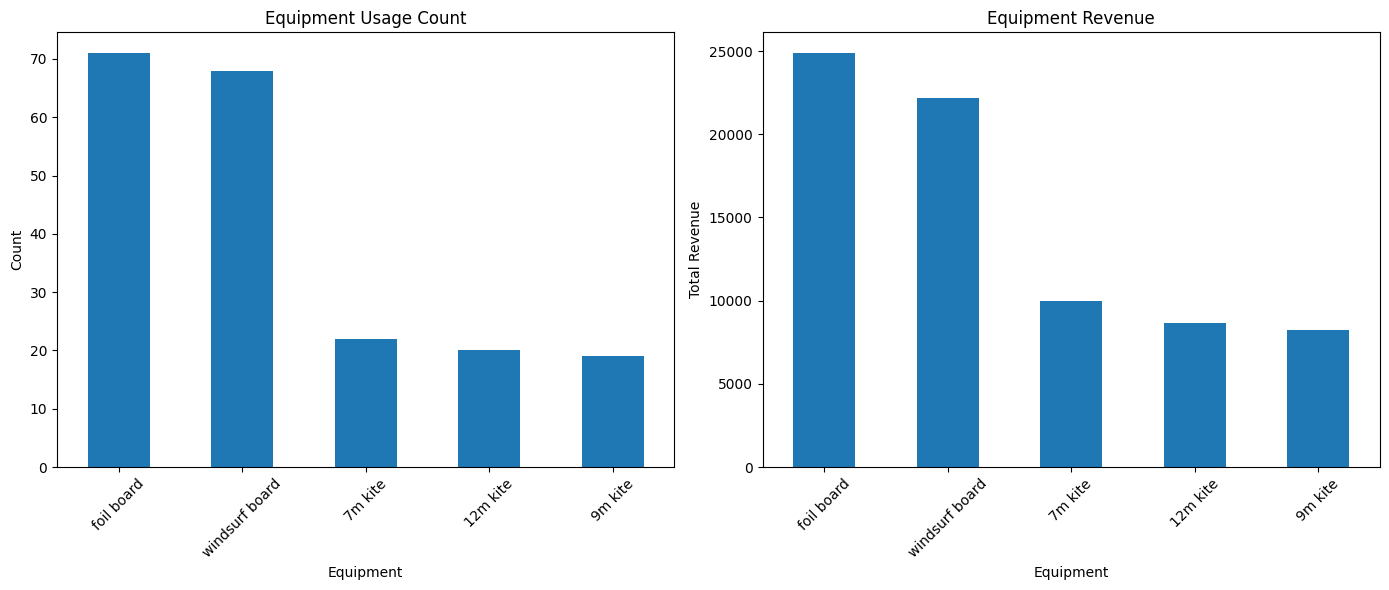

In [87]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for Equipment Usage Count
equipment_usage_count.plot(kind='bar', ax=axes[0])
axes[0].set_title('Equipment Usage Count')
axes[0].set_xlabel('Equipment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart for Equipment Revenue
equipment_revenue.plot(kind='bar', ax=axes[1])
axes[1].set_title('Equipment Revenue')
axes[1].set_xlabel('Equipment')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plots
plt.show()

## Equipment Utilization Insights

## Equipment Utilization Insights

### Data Analysis Key Findings

*   **Most Used Equipment**: 'Foil board' is the most frequently used equipment (71 times), followed by 'windsurf board' (68 times).
*   **Highest Revenue Generating Equipment**: 'Foil board' generates the highest total revenue ($24,882), closely followed by 'windsurf board' ($22,197).
*   **Kitesurf Equipment Usage and Revenue**: The '7m kite', '12m kite', and '9m kite' are used less frequently (22, 20, and 19 times respectively) and generate lower total revenues ($9,984, $8,632, and $8,240 respectively) compared to foil and windsurf boards.
*   **Correlation between Usage and Revenue**: There is a strong positive correlation between equipment usage count and total revenue generated, meaning the more an equipment is used, the more revenue it tends to generate.

### Insights or Next Steps

*   **Focus on High-Demand Equipment**: Given that 'foil board' and 'windsurf board' are both highly utilized and high-revenue generators, the school should ensure optimal maintenance and availability of these items. Consider investing in more of these popular items to meet demand and prevent loss of potential bookings.
*   **Review Kitesurf Equipment Strategy**: The lower usage and revenue for kitesurf equipment (7m, 9m, 12m kites) might indicate lower demand, less availability, or less appealing pricing for kitesurfing lessons. The school could:
    *   **Investigate Demand**: Conduct surveys or market research to understand current demand for kitesurfing vs. wingfoil/windsurf.
    *   **Marketing & Promotions**: Implement targeted marketing campaigns or promotions to boost kitesurfing lesson bookings.
    *   **Equipment Assessment**: Evaluate the condition and modernity of kitesurf equipment. Older or less efficient gear might deter students.
*   **Pricing Strategy**: Review pricing for each equipment type. While 'foil board' and 'windsurf board' are performing well, a slight price increase might be feasible during peak seasons without significantly impacting demand.
*   **Maintenance Schedules**: Prioritize maintenance and replacement for 'foil boards' and 'windsurf boards' due to their high usage to minimize downtime and ensure safety and customer satisfaction.


## SQL Analysis

In this section, we query the SQLite database directly using SQL to extract business insights.

## Connect to database

In [58]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("watersports.db")

## Preview table

In [59]:
query = "SELECT * FROM bookings LIMIT 5"
pd.read_sql(query, conn)

,date,student_name,instructor,sport,equipment,price,duration_hours
0,2025-01-08,Pedro Santos,Julia,wingfoil,foil board,360,3.00
1,2025-04-08,Ana Costa,Marcos,wingfoil,foil board,363,1.00
2,2025-07-17,Ana Costa,Julia,kitesurf,7m kite,497,1.00
3,2025-09-19,Pedro Santos,Pedro,kitesurf,7m kite,464,1.50
4,2025-08-07,Carla Mendes,Pedro,wingfoil,foil board,381,1.00


## Revenue by instructor (SQL version)

In [60]:
query = """
SELECT
    instructor,
    COUNT(*) AS total_sessions,
    SUM(price) AS total_revenue,
    AVG(price) AS avg_price
FROM bookings
GROUP BY instructor
ORDER BY total_revenue DESC
"""

pd.read_sql(query, conn)

,instructor,total_sessions,total_revenue,avg_price
0,Pedro,120,45294,377.45
1,Julia,106,39382,371.53
2,Fernanda,96,35798,372.90
3,Marcos,78,27396,351.23


## Profit per session (SQL)

In [61]:
query = """
SELECT
    instructor,
    AVG(price - (duration_hours * 50)) AS avg_profit
FROM bookings
GROUP BY instructor
ORDER BY avg_profit DESC
"""

pd.read_sql(query, conn)

,instructor,avg_profit
0,Pedro,280.78
1,Fernanda,274.98
2,Julia,274.83
3,Marcos,255.72


## Revenue by month (SQL)

In [63]:
query = """
SELECT
    strftime('%m', date) AS month,
    SUM(price) AS total_revenue
FROM bookings
GROUP BY month
ORDER BY month
"""

pd.read_sql(query, conn)

,month,total_revenue
0,01,20386
1,02,17384
2,03,10770
3,04,8280
4,05,7010
5,06,12878
6,07,14540
7,08,13746
8,09,10128
9,10,9710


## Profit by duration

In [62]:
query = """
SELECT
    duration_hours,
    AVG(price - (duration_hours * 50)) AS avg_profit
FROM bookings
GROUP BY duration_hours
ORDER BY duration_hours
"""

pd.read_sql(query, conn)

,duration_hours,avg_profit
0,1.00,316.94
1,1.50,302.21
2,2.00,281.69
3,2.50,230.88
4,3.00,220.41


## Close connection

In [64]:
conn.close()

### Executive Summary: Kitesurf School Analytics

#### a. Introduction/Purpose of the Analysis

This project aimed to leverage data systems and analytics to enhance operational efficiency and profitability within the watersports industry. By simulating a kitesurf school environment, we integrated database design, data analysis, and visualization techniques to uncover critical patterns in booking behavior, pricing strategies, and equipment utilization. The ultimate goal is to apply technology and AI to optimize real-world sports and hospitality operations, providing data-driven insights for improved decision-making.

#### b. Key Findings

*   **Seasonal Revenue Trends:** January, July, and August consistently represent the highest total revenue months. Wingfoil is a significant revenue driver, particularly in January and August, while Windsurf peaks in January, February, and August. Kitesurf sees its strongest performance in July and November. April and May are identified as the lowest revenue months across all sports, indicating an off-peak season. Kitesurf also demonstrates the highest average revenue per hour ($269.76).

*   **Instructor Profitability:** Pedro is the highest contributor to both total profit ($16,847.00) and average profit per session ($280.78), indicating strong productivity and efficiency. Julia follows closely with substantial contributions. Fernanda shows strong performance in specific peak months (June, August, January) but also experienced a zero-profit month (September). Marcos consistently has the lowest total profit ($9,973.00) and average profit per session ($255.72) among the instructors.

*   **Profit vs. Session Duration:** A clear inverse relationship exists between session duration and average profit per session. 1-hour sessions are the most profitable, averaging $316.94, while 3-hour sessions are the least profitable, averaging $220.41. This suggests that longer sessions may be undervalued.

#### c. Actionable Insights and Recommendations

*   **Pricing Strategy Optimization**: Re-evaluate the pricing structure for longer sessions to ensure they are adequately profitable, potentially by increasing the hourly rate for extended durations or creating value-added packages that justify longer sessions while maintaining healthy profit margins.

*   **Targeted Marketing and Resource Allocation**: Develop targeted marketing campaigns for specific sports during their peak months (e.g., Wingfoil/Windsurf in January/August, Kitesurf in July/November) and implement strategies (promotions, new services) to mitigate the consistent revenue dip observed in April and May.

*   **Instructor Performance Review**: Investigate the reasons behind Fernanda's zero profit in September and Marcos's consistently lower profit figures to understand potential underlying issues such as workload allocation, vacation periods, or specific market demand for their services. Develop targeted training or incentive programs as needed.